## 1. Import des bibliothèques

In [1]:
from pathlib import Path
import random
import hashlib

from PIL import Image
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
import sys
import torch
from torchvision import models
from torchvision.io import read_image, ImageReadMode
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import adjusted_rand_score
from sklearn.model_selection import train_test_split
from torch.utils.data import TensorDataset, DataLoader
import time


In [2]:
debut_notebook = time.perf_counter()

In [3]:
dossier_dataset = Path("mri_dataset_brain_cancer_oc")

print("Le dossier existe :", dossier_dataset.is_dir())

Le dossier existe : True


## Etape 1: Import des données et exploration des radios

Le dataset est organisé en deux répertoires: Un avec label et un sans label

normal : Image labellisée comme ne présentant pas de tumeur
cancer : Radio labelisée comme présentant une tumeur cancereuse

Le fichier .txt décerit le contenu du dataset: **1 500 images**, au format **JPEG**, dont 100 étiquetées et 1 400 sans label.

In [4]:
chemins_images = sorted(dossier_dataset.rglob("*.jpg"))

print("Nombre total d'images :", len(chemins_images))
print("Nombre annoncé dans le descriptif :", 1500)
print("Écart au descriptif :", len(chemins_images) - 1500)

Nombre total d'images : 1506
Nombre annoncé dans le descriptif : 1500
Écart au descriptif : 6


Comptons maintenant les images de chaque dossier.


In [5]:
dossiers = ["avec_labels/cancer", "avec_labels/normal", "sans_label"]
effectifs = []

for dossier in dossiers:
    fichiers = list((dossier_dataset / dossier).glob("*.jpg"))
    effectifs.append({
        "Dossier": dossier,
        "Nombre d'images": len(fichiers),
    })

tableau_effectifs = pd.DataFrame(effectifs)
display(tableau_effectifs)

,Dossier,Nombre d'images
0,avec_labels/cancer,50
1,avec_labels/normal,50
2,sans_label,1406


Ouverture d'une image et lecture de ses propriétés

In [6]:
chemin_exemple = chemins_images[0]

with Image.open(chemin_exemple) as image:
    print("Fichier :", chemin_exemple.name)
    print("Dossier :", chemin_exemple.parent.relative_to(dossier_dataset))
    print("Format :", image.format)
    print("Largeur :", image.width, "pixels")
    print("Hauteur :", image.height, "pixels")
    print("Mode de couleur :", image.mode)
    print("Canaux :", image.getbands())
    pixels = np.array(image)

print("Forme du tableau NumPy :", pixels.shape)

Fichier : 05340cd4-3bb2-459d-9937-bf27d52d8351.jpg
Dossier : avec_labels\cancer
Format : JPEG
Largeur : 512 pixels
Hauteur : 512 pixels
Mode de couleur : RGB
Canaux : ('R', 'G', 'B')
Forme du tableau NumPy : (512, 512, 3)


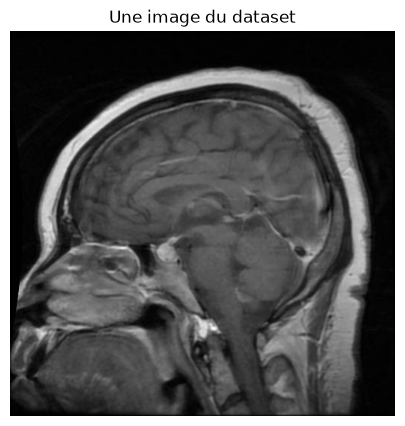

In [7]:
plt.figure(figsize=(5, 5))
plt.imshow(pixels)
plt.title("Une image du dataset")
plt.axis("off")
plt.show()

Affichage de quelques exemples de chaque dossier

random.seed(42) permet de retrouver la même sélection si rééxécution

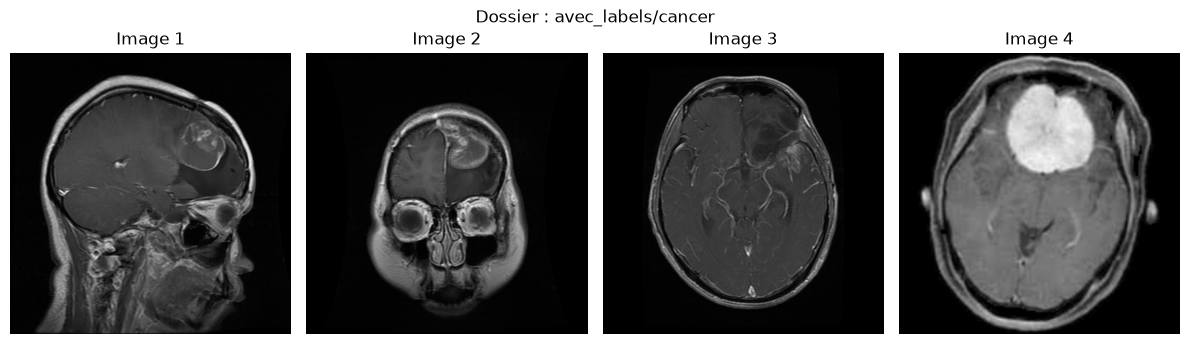

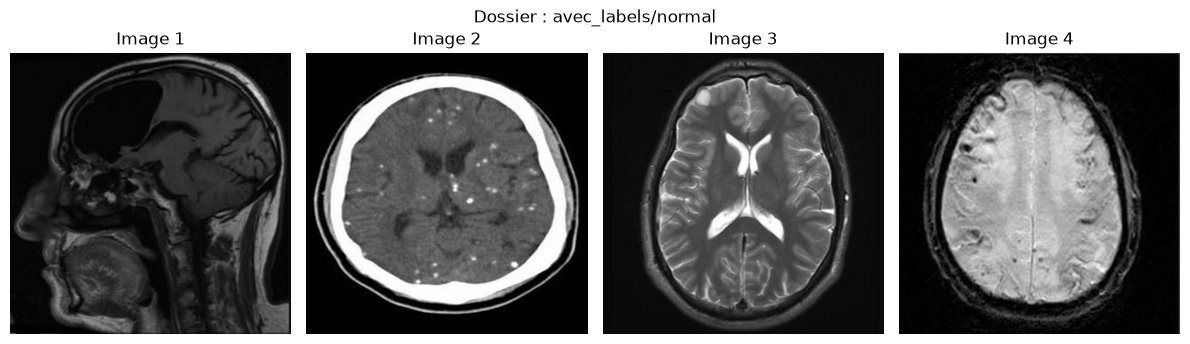

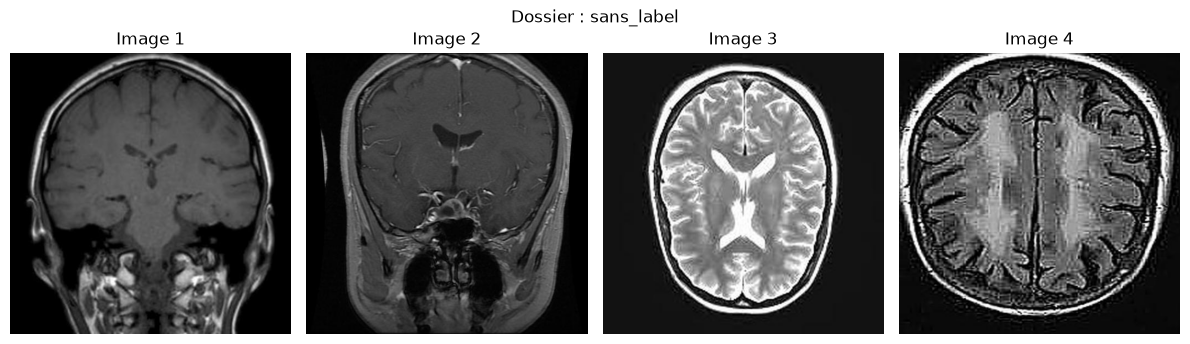

In [8]:
random.seed(42)

for dossier in dossiers:
    fichiers = sorted((dossier_dataset / dossier).glob("*.jpg"))
    exemples = random.sample(fichiers, min(4, len(fichiers)))

    plt.figure(figsize=(12, 3.5))
    for numero, chemin in enumerate(exemples, start=1):
        with Image.open(chemin) as image:
            pixels_exemple = np.array(image)

        plt.subplot(1, 4, numero)
        plt.imshow(pixels_exemple)
        plt.title(f"Image {numero}")
        plt.axis("off")

    plt.suptitle(f"Dossier : {dossier}")
    plt.tight_layout()
    plt.show()

échantillon de 100 images
Vérifications des dimensions, du mode de couleur, du nombre de canaux,
le format et la lisibilité 

In [9]:
random.seed(42)
echantillon = random.sample(chemins_images, min(100, len(chemins_images)))

print("Nombre d'images à vérifier :", len(echantillon))

Nombre d'images à vérifier : 100


Pour chaque fichier, appel de `image.load()` pour lire
ses pixels. Ses caractéristiques sont ajoutées à une liste.

In [10]:
caracteristiques = []
erreurs = []

for chemin in echantillon:
    try:
        with Image.open(chemin) as image:
            image.load()
            caracteristiques.append({
                "Fichier": chemin.name,
                "Dossier": str(chemin.parent.relative_to(dossier_dataset)),
                "Largeur": image.width,
                "Hauteur": image.height,
                "Mode": image.mode,
                "Canaux": len(image.getbands()),
                "Format": image.format,
            })
    except OSError as erreur:
        erreurs.append({"Fichier": str(chemin), "Erreur": str(erreur)})

controle = pd.DataFrame(caracteristiques)
display(controle.head())

,Fichier,Dossier,Largeur,Hauteur,Mode,Canaux,Format
0,de4a58ef-0572-499a-8b39-437d6605102e.jpg,sans_label,512,512,RGB,3,JPEG
1,1567a15d-5f22-46ca-a77c-cd88ee60b7fd.jpg,sans_label,512,512,RGB,3,JPEG
2,09316c60-86c8-4f24-934e-8d433b8b9d72.jpg,avec_labels\normal,512,512,RGB,3,JPEG
3,5674a7bf-6fe6-4c43-b574-fdd81608e18b.jpg,sans_label,512,512,RGB,3,JPEG
4,4a4822ad-22e0-4dac-a072-18fe2824cc9f.jpg,sans_label,512,512,RGB,3,JPEG


Regroupons les images pour vérifier qu'elles ont les mêmes caractéristiques

In [11]:
resume = controle.groupby(["Largeur", "Hauteur", "Mode", "Canaux"]).size()
display(resume.to_frame("Nombre d'images"))
display(controle["Format"].value_counts().to_frame("Nombre d'images"))

print("Images lisibles dans l'échantillon :", len(controle))
print("Erreurs de lecture :", len(erreurs))

if erreurs:
    display(pd.DataFrame(erreurs))

,,,,Nombre d'images
Largeur,Hauteur,Mode,Canaux,
512,512,RGB,3,100


,Nombre d'images
Format,
JPEG,100


Images lisibles dans l'échantillon : 100
Erreurs de lecture : 0


Recherche de doublons

In [12]:


images_vues = {}
doublons = []

for chemin in chemins_images:
    with Image.open(chemin) as image:
        image_rgb = image.convert("RGB")
        empreinte = hashlib.sha256(image_rgb.tobytes()).hexdigest()
        signature = (image_rgb.size, empreinte)

    if signature in images_vues:
        doublons.append((images_vues[signature], chemin))
    else:
        images_vues[signature] = chemin

print("Nombre d'images examinées :", len(chemins_images))
print("Nombre de doublons :", len(doublons))

display(pd.DataFrame(doublons, columns=["Première image", "Copie"]))

Nombre d'images examinées : 1506
Nombre de doublons : 96


,Première image,Copie
0,mri_dataset_brain_cancer_oc\avec_labels\normal...,mri_dataset_brain_cancer_oc\avec_labels\normal...
1,mri_dataset_brain_cancer_oc\avec_labels\normal...,mri_dataset_brain_cancer_oc\sans_label\04dd2b7...
2,mri_dataset_brain_cancer_oc\avec_labels\normal...,mri_dataset_brain_cancer_oc\sans_label\16a1699...
3,mri_dataset_brain_cancer_oc\avec_labels\normal...,mri_dataset_brain_cancer_oc\sans_label\18599c4...
4,mri_dataset_brain_cancer_oc\avec_labels\normal...,mri_dataset_brain_cancer_oc\sans_label\194106c...
...,...,...
91,mri_dataset_brain_cancer_oc\sans_label\1212636...,mri_dataset_brain_cancer_oc\sans_label\f84cb0d...
92,mri_dataset_brain_cancer_oc\avec_labels\cancer...,mri_dataset_brain_cancer_oc\sans_label\f946618...
93,mri_dataset_brain_cancer_oc\sans_label\abac225...,mri_dataset_brain_cancer_oc\sans_label\fa8ec37...
94,mri_dataset_brain_cancer_oc\sans_label\f9d60d2...,mri_dataset_brain_cancer_oc\sans_label\fcf1c2e...


On effectue la recherche de doublons par dossier cette fois ci

In [13]:


for dossier in ["sans_label", "avec_labels/cancer", "avec_labels/normal"]:
    images_vues = {}
    doublons_dossier = []

    chemins = sorted((dossier_dataset / dossier).glob("*.jpg"))

    for chemin in chemins:
        with Image.open(chemin) as image:
            image_rgb = image.convert("RGB")
            empreinte = hashlib.sha256(image_rgb.tobytes()).hexdigest()
            signature = (image_rgb.size, empreinte)

        if signature in images_vues:
            doublons_dossier.append((images_vues[signature], chemin))
        else:
            images_vues[signature] = chemin

    print(f"{dossier} : {len(doublons_dossier)} doublons")

    if doublons_dossier:
        display(pd.DataFrame(
            doublons_dossier,
            columns=["Première image", "Copie"]
        ))

sans_label : 64 doublons


,Première image,Copie
0,mri_dataset_brain_cancer_oc\sans_label\11c7876...,mri_dataset_brain_cancer_oc\sans_label\21797d4...
1,mri_dataset_brain_cancer_oc\sans_label\01d4471...,mri_dataset_brain_cancer_oc\sans_label\3a1ca11...
2,mri_dataset_brain_cancer_oc\sans_label\3058ed0...,mri_dataset_brain_cancer_oc\sans_label\3a57247...
3,mri_dataset_brain_cancer_oc\sans_label\1d9eb25...,mri_dataset_brain_cancer_oc\sans_label\4ab4a1f...
4,mri_dataset_brain_cancer_oc\sans_label\070e468...,mri_dataset_brain_cancer_oc\sans_label\55e150d...
...,...,...
59,mri_dataset_brain_cancer_oc\sans_label\9f94cc0...,mri_dataset_brain_cancer_oc\sans_label\f5b5021...
60,mri_dataset_brain_cancer_oc\sans_label\1212636...,mri_dataset_brain_cancer_oc\sans_label\f84cb0d...
61,mri_dataset_brain_cancer_oc\sans_label\abac225...,mri_dataset_brain_cancer_oc\sans_label\fa8ec37...
62,mri_dataset_brain_cancer_oc\sans_label\f9d60d2...,mri_dataset_brain_cancer_oc\sans_label\fcf1c2e...


avec_labels/cancer : 0 doublons
avec_labels/normal : 1 doublons


,Première image,Copie
0,mri_dataset_brain_cancer_oc\avec_labels\normal...,mri_dataset_brain_cancer_oc\avec_labels\normal...


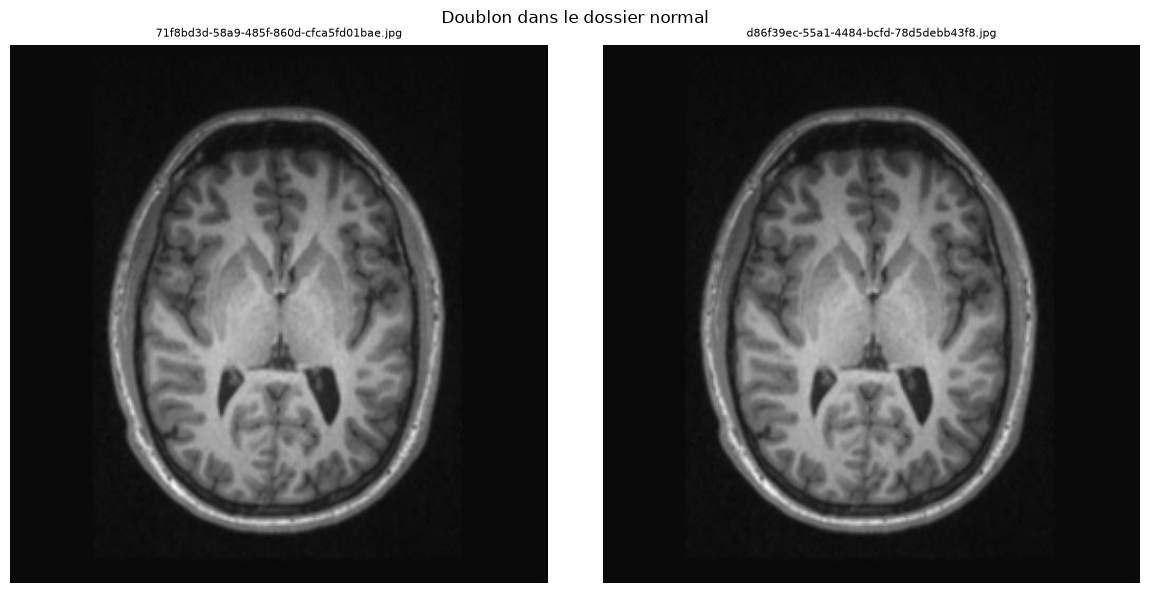

In [14]:
dossier_normal = Path("mri_dataset_brain_cancer_oc/avec_labels/normal")

fichiers = [
    "71f8bd3d-58a9-485f-860d-cfca5fd01bae.jpg",
    "d86f39ec-55a1-4484-bcfd-78d5debb43f8.jpg",
]

plt.figure(figsize=(12, 6))

for numero, nom in enumerate(fichiers, start=1):
    with Image.open(dossier_normal / nom) as image:
        plt.subplot(1, 2, numero)
        plt.imshow(image)

    plt.title(nom, fontsize=8)
    plt.axis("off")

plt.suptitle("Doublon dans le dossier normal")
plt.tight_layout()
plt.show()

Conclusion

- Le comptage donne **1 506 images JPEG** : 50 dans cancer, 50 dans normal
  et 1 406 dans sans_label.
- Les deux classes étiquetées sont équilibrées. 
- Le dossier sans label contient **six images de plus** qque l'enoncé
- Les **100 images contrôlées** mesurent **512 × 512 pixels** et sont stockées
  en **RGB, avec trois canaux**.
- Aucune erreur de lecture n'a été rencontrée dans cet échantillon.
- Les images montrent différentes orientations de coupe et différents cadrages.
- La place occupée par le cerveau, le contraste et la netteté apparente varient.
- Les exemples apparaissent principalement en niveaux de gris malgré le stockage RGB.
- Une même taille de 512 × 512 pixels ne garantit pas une qualité visuelle uniforme.
- Le data set contient 96 doublons
  
  --> Ces doublons seront à traiter

Traitement des doublons

In [15]:
nombre_images_avant = len(chemins_images)

# Récupérer les chemins des copies supplémentaires.
copies_a_ecarter = {
    copie for premiere_image, copie in doublons
}

# Conserver uniquement la première occurrence de chaque image.
chemins_images = [
    chemin for chemin in chemins_images
    if chemin not in copies_a_ecarter
]

print("Images avant filtrage :", nombre_images_avant)
print("Copies écartées :", nombre_images_avant - len(chemins_images))
print("Images conservées pour l'étape 2 :", len(chemins_images))

Images avant filtrage : 1506
Copies écartées : 96
Images conservées pour l'étape 2 : 1410


## Etape 2: Prétraitement et extraction des features

### Mesurer la durée et la RAM

`mesurer_ressources`  calcul et suit la RAM du processus Python toutes les 0,05 seconde avec `psutil`.
Chaque mesure conserve la RAM au départ, le pic observé et la hausse maximale, en Mio. Les pauses entre cellules ne sont pas comptées 

In [16]:
from contextlib import contextmanager
from threading import Event, Thread
import psutil

mesures_ressources = {}
processus_python = psutil.Process()

@contextmanager
def mesurer_ressources(nom, groupe="Création du modèle"):
    if torch.cuda.is_available():
        torch.cuda.synchronize()
    ram_depart = processus_python.memory_info().rss
    pic_ram = [ram_depart]
    arret = Event()

    def suivre_ram():
        while not arret.wait(0.05):
            pic_ram[0] = max(pic_ram[0], processus_python.memory_info().rss)

    suivi = Thread(target=suivre_ram, daemon=True)
    suivi.start()
    debut = time.perf_counter()
    try:
        yield
    finally:
        if torch.cuda.is_available():
            torch.cuda.synchronize()
        duree = time.perf_counter() - debut
        arret.set()
        suivi.join()
        pic_ram[0] = max(pic_ram[0], processus_python.memory_info().rss)
        mesures_ressources[nom] = {
            "Groupe": groupe,
            "Opération": nom,
            "Durée (s)": duree,
            "RAM au départ (Mio)": ram_depart / 1024**2,
            "Pic RAM (Mio)": pic_ram[0] / 1024**2,
            "Hausse maximale (Mio)": (pic_ram[0] - ram_depart) / 1024**2,
        }

print("Mesure de la durée et du pic de RAM prête.")

Mesure de la durée et du pic de RAM prête.



Choix d'une version préentrainé de ResNet18: IMAGENET1K_V1
définition de la focntion prétraitement qui réalisera le redimensionnement des images, le recadrage, la conversion et la normalisation


In [17]:


poids = models.ResNet18_Weights.IMAGENET1K_V1
pretraitement = poids.transforms()
print(pretraitement)

ImageClassification(
    crop_size=[224]
    resize_size=[256]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BILINEAR
)


Egalisation des histogrammes

In [18]:
from torchvision.transforms.functional import equalize

# Egaliser les pixels uint8 avant la normalisation ImageNet.
pretraitement_imagenet = poids.transforms()

def pretraitement(image):
    image_egalisee = equalize(image)
    return pretraitement_imagenet(image_egalisee)

print("Egalisation des histogrammes avant le prétraitement ImageNet.")
print(pretraitement_imagenet)

Egalisation des histogrammes avant le prétraitement ImageNet.
ImageClassification(
    crop_size=[224]
    resize_size=[256]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BILINEAR
)


Application de "pretraitement" à chaque image du dataset
Stockage du resultat dans la liste images_preparees

La durée et le pic de RAM de cette cellule sont mesurés.

In [19]:
with mesurer_ressources('Préparation et égalisation des images'):
    images_preparees = []

    for chemin in chemins_images:
        image = read_image(str(chemin), mode=ImageReadMode.RGB)
        images_preparees.append(pretraitement(image))

    print("Nombre d'images préparées :", len(images_preparees))
    print("Forme d'une image préparée :", tuple(images_preparees[0].shape))
    print("Type des valeurs :", images_preparees[0].dtype)

Nombre d'images préparées : 1410
Forme d'une image préparée : (3, 224, 224)
Type des valeurs : torch.float32


Chargement de ResNet avec le poids préentrainé précédement choisi
Gel des couches convutionelles avec `requires_grad = False` (cela gele tous les paramètres du modele, y compris les couches convutionelles donc cela repond à notre bespoin)

On prépare le modèle pour renvoyer les 512 nombres décrivant l’image avec identity(), puis modele.eval() pour utiliser le modele déjà entrainé

pui son verifie que les couches sont bien gelées en verifiant les paramètre entrainabels

La durée et le pic de RAM de cette cellule sont mesurés.

In [20]:
with mesurer_ressources('Chargement du modèle d’extraction'):
    modele = models.resnet18(weights=poids)

    for parametre in modele.parameters():
        parametre.requires_grad = False

    modele.fc = torch.nn.Identity()
    modele.eval()

    print("Nombre de paramètres entraînables :", sum(
        parametre.numel() for parametre in modele.parameters() if parametre.requires_grad
    ))

Nombre de paramètres entraînables : 0


Extractions des embeddings des images préparés:
- On traite les images préparées par lots de 16 : pour chaque image, le modèle crée un vecteur de 512 nombres décrivant l’image.
- On ajoute avec append() chaque lot de 16 vecteurs dans blocs_features.
- Après la boucle, on concatène avec np.concatenate() les blocs en un tableau unique.

La durée et le pic de RAM de cette cellule sont mesurés.

In [21]:
with mesurer_ressources('Extraction des embeddings layer4'):
    taille_lot = 16
    blocs_features = []

    for debut in range(0, len(images_preparees), taille_lot):
        images_lot = images_preparees[debut:debut + taille_lot]
        lot = torch.stack(images_lot)
        features_lot = modele(lot).numpy()
        blocs_features.append(features_lot)

        nombre_traite = debut + len(images_lot)
        if debut % (taille_lot * 10) == 0 or nombre_traite == len(images_preparees):
            print(f"Images traitées : {nombre_traite} / {len(images_preparees)}")

    matrice_features = np.concatenate(blocs_features, axis=0)
    print("Forme de la matrice de features :", matrice_features.shape)

Images traitées : 16 / 1410

Images traitées : 176 / 1410


Images traitées : 336 / 1410


Images traitées : 496 / 1410


Images traitées : 656 / 1410


Images traitées : 816 / 1410


Images traitées : 976 / 1410


Images traitées : 1136 / 1410


Images traitées : 1296 / 1410


Images traitées : 1410 / 1410
Forme de la matrice de features : (1410, 512)


### Essai d'une couche intermédiaire

- Réutiliser les couches gelées de `modele` jusqu'à `layer3`, en arrêtant avant `layer4`.
- Traiter `images_preparees` par lots de 16 et afficher les dimensions des deux matrices.
- Cet essai reste en mémoire et ne remplace pas `matrice_features`, qui contient les embeddings habituels de 512 dimensions. La durée et le pic de RAM de cet essai sont mesurés.

In [22]:
with mesurer_ressources("Essai des embeddings layer3"):
    modele_intermediaire = torch.nn.Sequential(
        modele.conv1, modele.bn1, modele.relu, modele.maxpool,
        modele.layer1, modele.layer2, modele.layer3,
        torch.nn.AdaptiveAvgPool2d((1, 1)),
        torch.nn.Flatten(),
    )
    modele_intermediaire.eval()
    blocs_intermediaires = []

    with torch.no_grad():
        for debut in range(0, len(images_preparees), taille_lot):
            lot = torch.stack(images_preparees[debut:debut + taille_lot])
            blocs_intermediaires.append(modele_intermediaire(lot).numpy())

    matrice_features_intermediaires = np.concatenate(blocs_intermediaires, axis=0)

display(pd.DataFrame({
    "Embeddings": ["Habituels : layer4", "Intermédiaires : layer3"],
    "Nombre d'images": [len(matrice_features), len(matrice_features_intermediaires)],
    "Dimensions du vecteur": [matrice_features.shape[1], matrice_features_intermediaires.shape[1]],
}))

,Embeddings,Nombre d'images,Dimensions du vecteur
0,Habituels : layer4,1410,512
1,Intermédiaires : layer3,1410,256


Transformation de matrice_features en tableau pandas nommé features avec les colonnes de features numériques nommées feature_000 à feature_511.

La premiere colonne du tableau contient le chemin relatif de l'image

La durée et le pic de RAM de cette cellule sont mesurés.

In [23]:
with mesurer_ressources('Création du tableau de features'):
    colonnes_features = [f"feature_{numero:03d}" for numero in range(512)]
    features = pd.DataFrame(matrice_features, columns=colonnes_features)
    features.insert(0, "chemin", [
        chemin.relative_to(dossier_dataset).as_posix() for chemin in chemins_images
    ])

    print("Forme du tableau :", features.shape)
    display(features.head())

Forme du tableau : (1410, 513)


,chemin,feature_000,feature_001,feature_002,feature_003,feature_004,feature_005,feature_006,feature_007,feature_008,...,feature_502,feature_503,feature_504,feature_505,feature_506,feature_507,feature_508,feature_509,feature_510,feature_511
0,avec_labels/cancer/05340cd4-3bb2-459d-9937-bf2...,0.427526,1.104701,1.259578,0.924098,0.844503,0.227291,3.558283,0.464599,0.409301,...,0.175423,0.722892,0.229014,0.463602,0.738753,0.799519,0.140114,0.495545,0.677184,1.773725
1,avec_labels/cancer/0c6f3641-60d9-4a76-abe5-de8...,1.007464,0.752442,1.473015,1.305458,0.512743,0.181810,1.341346,0.928918,0.764854,...,0.291134,0.027832,1.492800,0.915966,0.374621,2.466911,1.044371,1.002122,0.440505,0.020950
2,avec_labels/cancer/0f718241-8f63-4b55-81ce-315...,3.150173,1.437924,1.317399,1.865557,0.621480,0.056884,0.638821,0.701905,0.582477,...,0.060915,0.753794,0.997981,1.027417,0.838848,1.636190,1.717380,1.792483,0.689735,0.066517
3,avec_labels/cancer/11a7a426-4806-401e-98b2-b96...,3.644768,1.381252,1.123359,0.504586,1.479506,0.002588,1.434988,0.111483,1.806750,...,1.228691,1.111359,0.922799,2.786146,1.676362,1.425793,0.150992,1.483571,1.135730,0.489560
4,avec_labels/cancer/1c043dbb-4623-4769-8e5e-022...,1.861621,0.778503,2.320081,0.980369,0.683174,0.018706,2.488118,0.771761,0.541069,...,0.182425,0.187410,0.875479,1.312932,0.364541,0.921728,0.531713,2.628400,0.000000,2.191155


Sauvegarde dans un tableau .csv pour l'utiliser par la suite

In [24]:
chemin_features = Path("resultats/etape2/features_resnet18.csv")
assert chemin_features.exists()

## Etape 3: modélisation non supervisée



Chargement du tableau CSV sauvegardé, puis séparation avant les transformations : train, validation et test forts ; train et test sans label.

La durée et le pic de RAM de cette cellule sont mesurés.

In [25]:
with mesurer_ressources('Lecture du CSV et séparation des ensembles'):
    features = pd.read_csv(chemin_features)

    masque_fort = features["chemin"].str.startswith("avec_labels/")
    masque_sans_label = features["chemin"].str.startswith("sans_label/")

    donnees_fortes = features.loc[masque_fort].copy()
    donnees_fortes["label_fort"] = donnees_fortes["chemin"].str.split("/").str[1]
    donnees_sans_label = features.loc[masque_sans_label].copy()

    # Réserver le test fort, puis la validation forte.
    fortes_train, fortes_test = train_test_split(
        donnees_fortes,
        test_size=0.2,
        stratify=donnees_fortes["label_fort"],
        random_state=42,
    )
    fortes_train, fortes_validation = train_test_split(
        fortes_train,
        test_size=0.2,
        stratify=fortes_train["label_fort"],
        random_state=42,
    )

    # Les images sans label sont séparées avant leur labellisation faible.
    sans_label_train, sans_label_test = train_test_split(
        donnees_sans_label,
        test_size=0.2,
        random_state=42,
    )

    print("Train fort :", len(fortes_train))
    print("Validation forte :", len(fortes_validation))
    print("Test fort :", len(fortes_test))
    print("Train sans label :", len(sans_label_train))
    print("Test sans label :", len(sans_label_test))

Train fort : 63
Validation forte : 16
Test fort : 20
Train sans label : 1048
Test sans label : 263


Standardisation des features de sans_label_train avec StandardScaler. Les paramètres sont appris uniquement sur cet ensemble. Affichage des dimensions et des premières lignes du tableau standardisé.

La durée et le pic de RAM de cette cellule sont mesurés.

In [26]:
with mesurer_ressources('Standardisation des embeddings'):
    X_features = sans_label_train[colonnes_features]

    standardisation = StandardScaler()
    X_standardise = standardisation.fit_transform(X_features)

    print("Forme des features du train sans label standardisées :", X_standardise.shape)
    display(pd.DataFrame(X_standardise, columns=colonnes_features).head())

Forme des features du train sans label standardisées : (1048, 512)


,feature_000,feature_001,feature_002,feature_003,feature_004,feature_005,feature_006,feature_007,feature_008,feature_009,...,feature_502,feature_503,feature_504,feature_505,feature_506,feature_507,feature_508,feature_509,feature_510,feature_511
0,0.995028,1.284422,1.921117,-0.483801,-0.552285,-0.640420,-0.031213,-0.647499,2.607581,0.266280,...,-1.205877,0.032552,0.298437,0.699903,0.745455,0.022585,0.293588,-0.691926,0.940962,-0.513008
1,-1.050579,-1.162886,-1.810365,1.724883,0.336961,-0.659382,-1.028645,3.602072,-1.089424,0.855245,...,0.703073,-0.889932,2.022210,-1.327908,-0.593040,1.524957,4.755811,-0.452856,-1.088294,1.273833
2,0.859233,1.743549,0.736567,-0.358300,0.081548,-0.642731,-0.151604,-0.558385,1.581523,0.858876,...,-1.070132,2.952054,0.090872,0.337174,0.846584,-0.352459,0.797273,-0.002185,0.257804,-1.161232
3,-0.389652,1.792934,0.901776,-0.880696,-0.337090,-0.626833,0.627818,0.562381,0.003364,-0.973740,...,-0.801489,-0.770780,1.122112,0.466274,2.215968,0.845378,-0.089319,-0.885149,-0.609775,-1.050167
4,0.760517,1.755104,1.518954,0.714497,1.696330,-0.552697,1.114565,-0.895014,-0.319856,1.163700,...,-1.120287,-0.479780,3.610913,-1.262984,0.089637,0.877110,-0.937632,-0.698248,-0.347851,-0.816080


Réduction à deux dimensions : la PCA est apprise uniquement sur le train sans label. Les ensembles forts et le test sans label sont transformés avec la standardisation et la PCA déjà apprises. Affichage des dimensions de chaque ensemble.

La durée et le pic de RAM de cette cellule sont mesurés.

In [27]:
with mesurer_ressources('PCA des embeddings'):
    pca = PCA(n_components=2, random_state=42)
    X_pca = pca.fit_transform(X_standardise)

    # Transformer séparément les données fortes, sans réapprentissage.
    X_fort_pca = pca.transform(standardisation.transform(
        fortes_train[colonnes_features]
    ))
    X_validation_pca = pca.transform(standardisation.transform(
        fortes_validation[colonnes_features]
    ))
    X_fort_test_pca = pca.transform(standardisation.transform(
        fortes_test[colonnes_features]
    ))

    # Transformer le test sans label avec les mêmes paramètres.
    X_test_pca = pca.transform(standardisation.transform(
        sans_label_test[colonnes_features]
    ))

    print("PCA train fort :", X_fort_pca.shape)
    print("PCA train sans label :", X_pca.shape)
    print("PCA validation forte :", X_validation_pca.shape)
    print("PCA test fort :", X_fort_test_pca.shape)
    print("PCA test sans label :", X_test_pca.shape)

PCA train fort : (63, 2)
PCA train sans label : (1048, 2)
PCA validation forte : (16, 2)
PCA test fort : (20, 2)
PCA test sans label : (263, 2)


Réalisation du clustering avec K-Means

- n_clusters=2 pour la spération en deux groupes, comme pour le dataset labélisé
- random_state=42 pour pouvori reproduirele clustering.

Modification : K-Means entraîné uniquement sur le train sans label.

La durée et le pic de RAM de cette cellule sont mesurés.

In [28]:
with mesurer_ressources('Clustering K-Means'):
    # X_pca contient uniquement le train sans label.
    kmeans = KMeans(n_clusters=2, random_state=42)
    groupes_kmeans_sans_label = kmeans.fit_predict(X_pca)

    display(pd.Series(groupes_kmeans_sans_label).value_counts().sort_index().to_frame("Nombre d'images"))

,Nombre d'images
0,565
1,483


Graphique illustrant les coordonées des images

Chaque point représente une image, placée selon ses deux coordonnées PCA. Sa couleur indique le groupe attribué par K-Means.

Modification : graphique du train sans label.

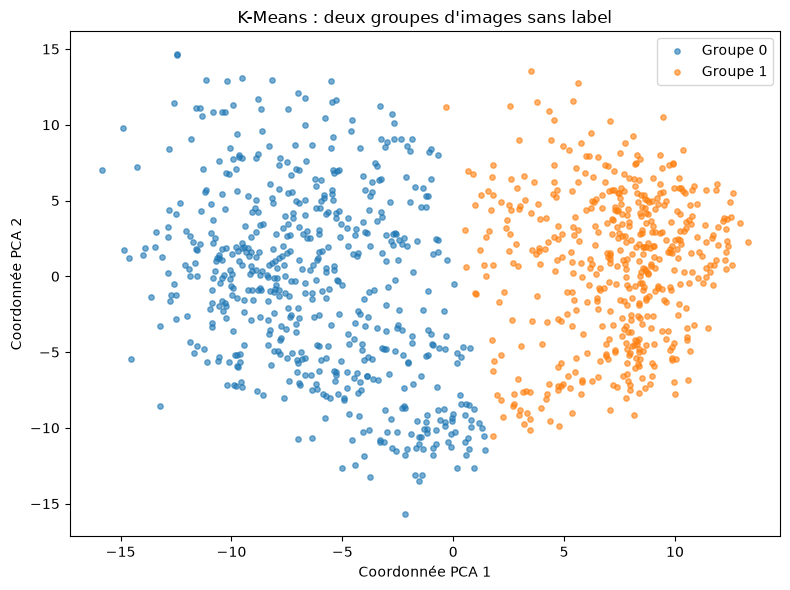

In [29]:
plt.figure(figsize=(8, 6))

for groupe in [0, 1]:
    selection = groupes_kmeans_sans_label == groupe
    plt.scatter(X_pca[selection, 0], X_pca[selection, 1],
                s=15, alpha=0.6, label=f"Groupe {groupe}")

plt.xlabel("Coordonnée PCA 1")
plt.ylabel("Coordonnée PCA 2")
plt.title("K-Means : deux groupes d'images sans label")
plt.legend()
plt.tight_layout()
plt.show()

K-Means répartit les images en deux groupes, principalement séparés par l'abscisse PCA (gauche vs droite). Les groupes présentent une dispersion interne. Cette représentation montre des différences entre les images, sans pour autant identifier chaque groupe comme étant: « normal » et « cancer ».

Réalisation du clustering avec DBSCAN

Choix de neuf combinaisaon à tester pour visualiser ensutie les resultats:
- eps (rayon du voisinage ): 0.5, 1.0, 2.0
- et repectivement min_samples (nombre minimum de points dans ce voisinage): 3, 5, 10.  ;

Chaque résultat est conservé dans essais_dbscan avec ses paramètres, ses numéros de groupes, le nombre de groupes et le nombre d'images hors groupe (-1).

DBSCAN entraîné uniquement sur le train sans label.

La durée et le pic de RAM de cette cellule sont mesurés.

In [30]:
with mesurer_ressources('Essais DBSCAN'):
    # Les neuf essais utilisent uniquement le train sans label.
    essais_dbscan = []

    for eps in [0.5, 1.0, 2.0]:
        for min_samples in [3, 5, 10]:
            dbscan_essai = DBSCAN(eps=eps, min_samples=min_samples)
            groupes_essai = dbscan_essai.fit_predict(X_pca)
            nombre_groupes_essai = len(set(groupes_essai) - {-1})
            nombre_hors_groupe_essai = int((groupes_essai == -1).sum())

            essais_dbscan.append({
                "eps": eps,
                "min_samples": min_samples,
                "groupes": groupes_essai,
                "nombre_groupes": nombre_groupes_essai,
                "nombre_hors_groupe": nombre_hors_groupe_essai,
            })

            print(f"eps={eps}, min_samples={min_samples} : "
                  f"{nombre_groupes_essai} groupe(s), "
                  f"{nombre_hors_groupe_essai} image(s) hors groupe")

eps=0.5, min_samples=3 : 93 groupe(s), 368 image(s) hors groupe
eps=0.5, min_samples=5 : 36 groupe(s), 706 image(s) hors groupe
eps=0.5, min_samples=10 : 2 groupe(s), 1028 image(s) hors groupe
eps=1.0, min_samples=3 : 15 groupe(s), 51 image(s) hors groupe
eps=1.0, min_samples=5 : 8 groupe(s), 112 image(s) hors groupe
eps=1.0, min_samples=10 : 12 groupe(s), 373 image(s) hors groupe
eps=2.0, min_samples=3 : 1 groupe(s), 8 image(s) hors groupe
eps=2.0, min_samples=5 : 1 groupe(s), 10 image(s) hors groupe
eps=2.0, min_samples=10 : 1 groupe(s), 18 image(s) hors groupe


Affichage d'un graphique pour chaque essai de paramètre avec DBSCAN: Une couleur représente chaque groupe ; les points hors groupe (`-1`) sont affichés en gris.



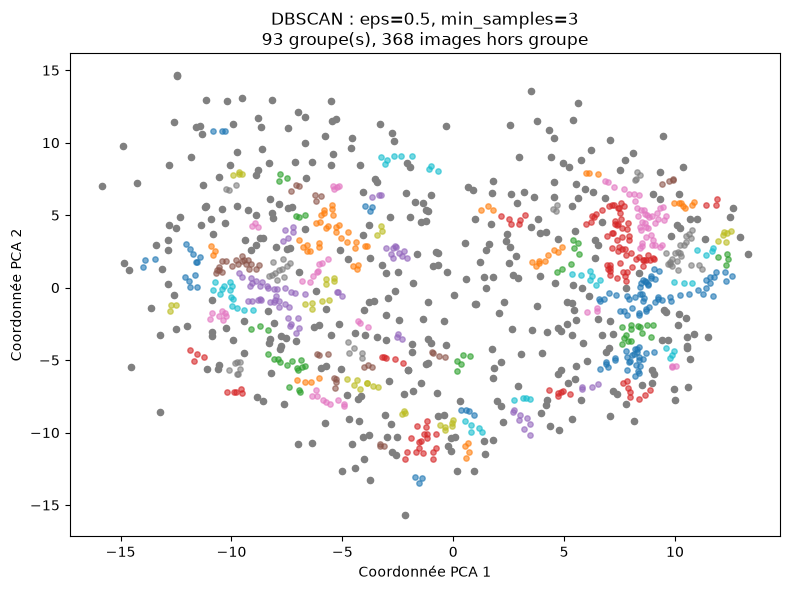

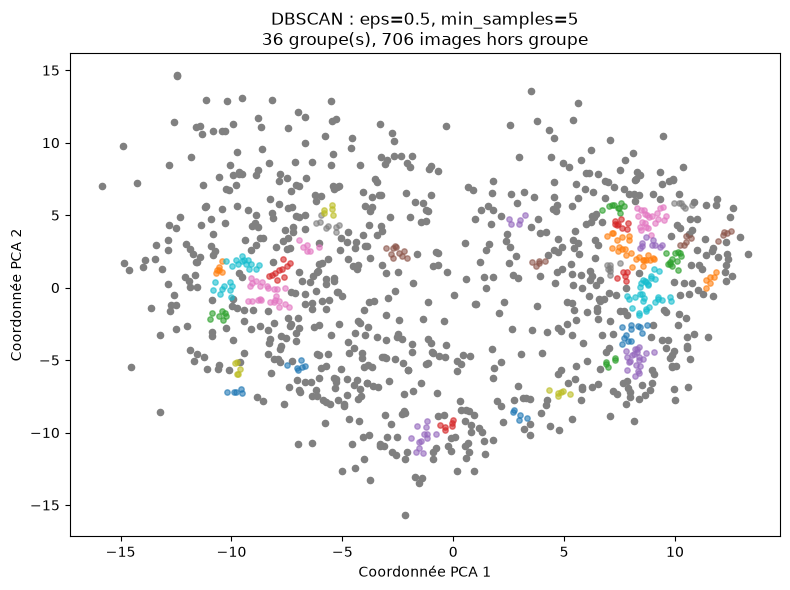

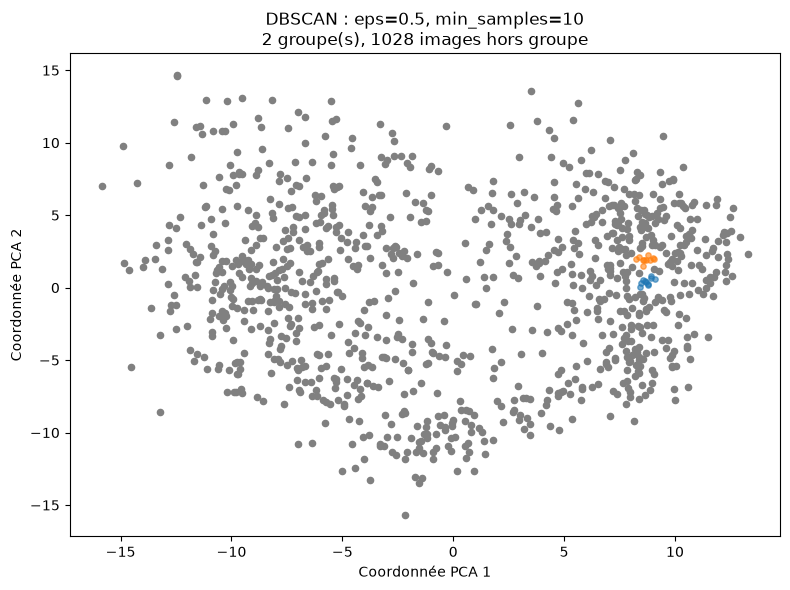

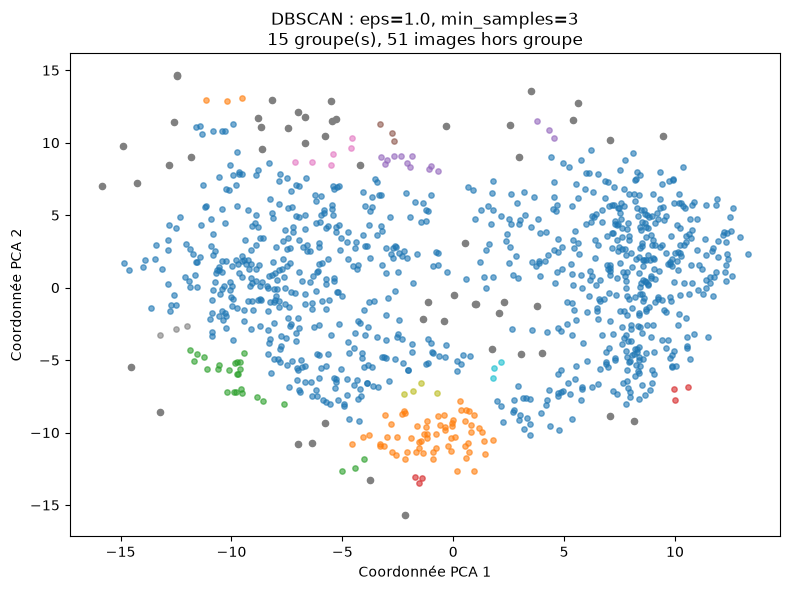

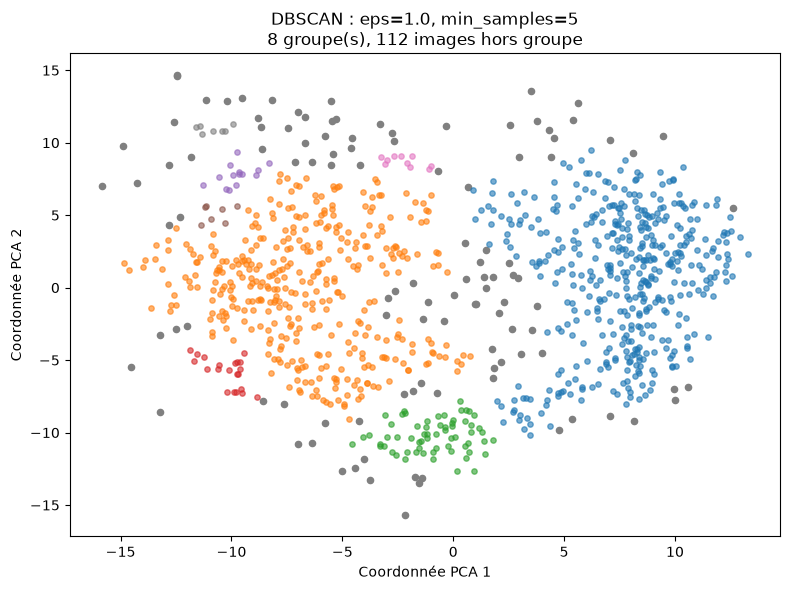

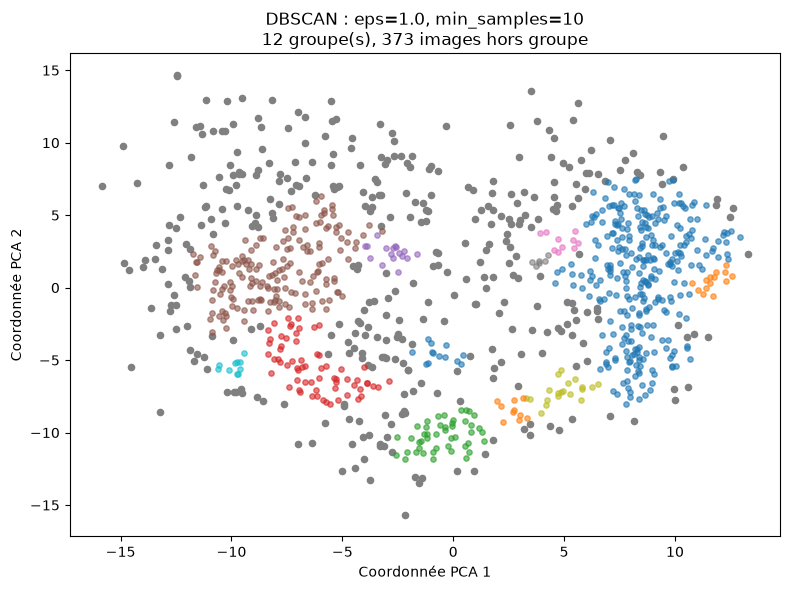

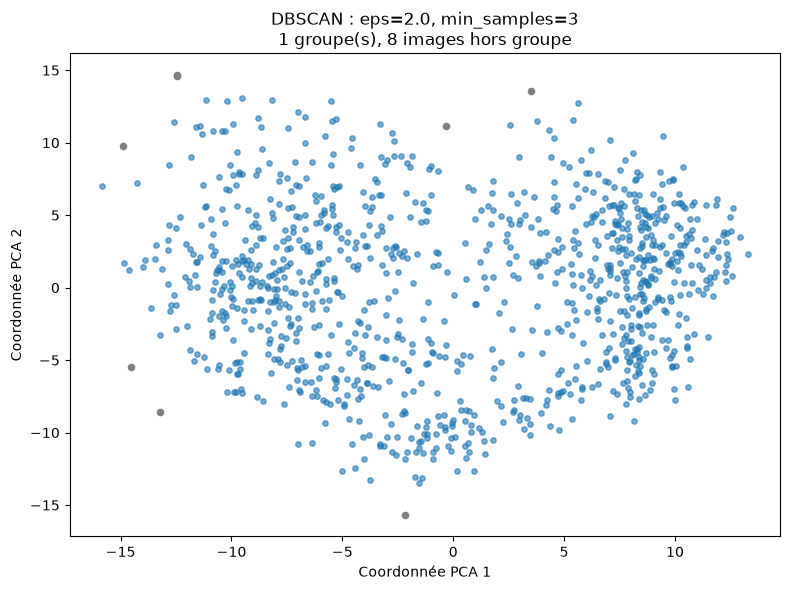

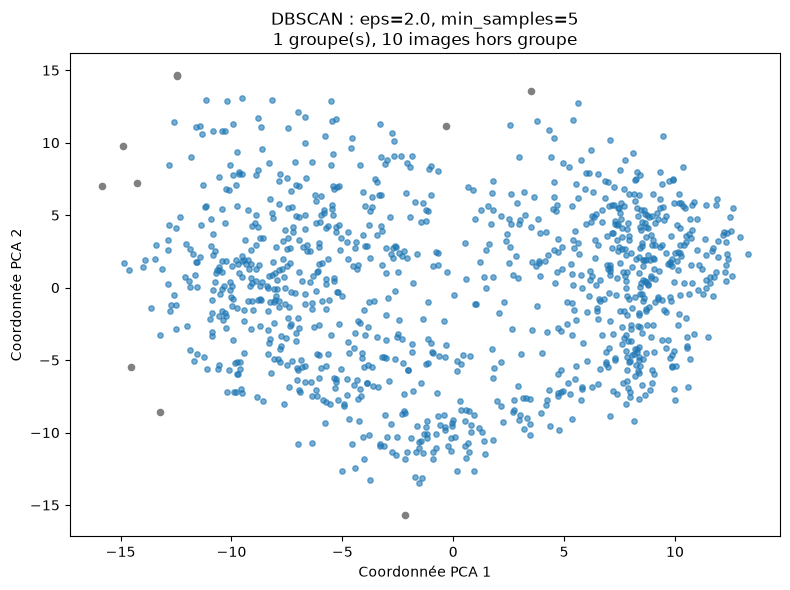

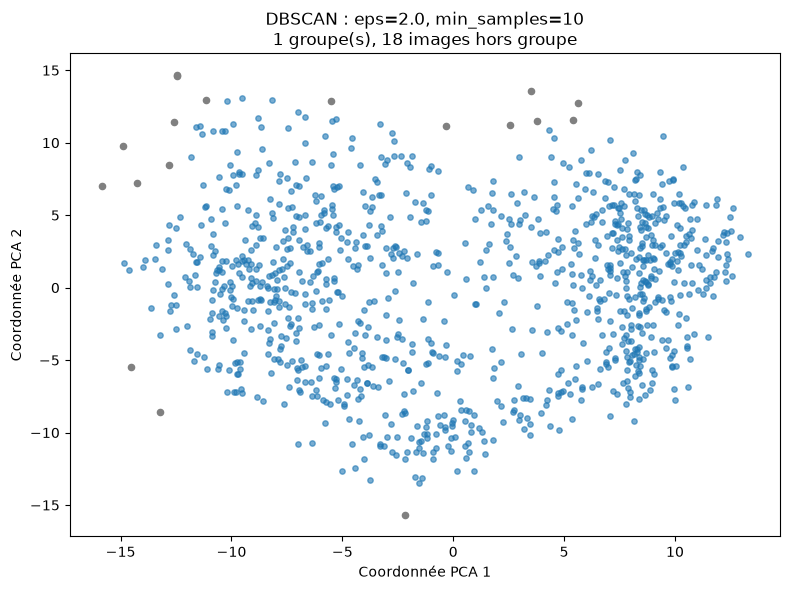

In [31]:
for essai in essais_dbscan:
    groupes_essai = essai["groupes"]
    plt.figure(figsize=(8, 6))

    for groupe in sorted(set(groupes_essai)):
        selection = groupes_essai == groupe
        if groupe == -1:
            plt.scatter(X_pca[selection, 0], X_pca[selection, 1],
                        s=20, color="gray", label="Hors groupe (-1)")
        else:
            plt.scatter(X_pca[selection, 0], X_pca[selection, 1],
                        s=15, alpha=0.6, label=f"Groupe {groupe}")

    plt.xlabel("Coordonnée PCA 1")
    plt.ylabel("Coordonnée PCA 2")
    plt.title(
        f"DBSCAN : eps={essai['eps']}, min_samples={essai['min_samples']}\n"
        f"{essai['nombre_groupes']} groupe(s), "
        f"{essai['nombre_hors_groupe']} images hors groupe"
    )
    plt.tight_layout()
    plt.show()

Avec `eps=0.5` et `min_samples=10`, DBSCAN produit deux groupes, mais laisse 1 028 des 1 048 images hors groupe. Les autres essais produisent un nombre de groupes différent de deux. Je conserve donc K-Means pour la labellisation faible : il répartit toutes les images en deux groupes.


### 3.9. Calcul du score ARI de K-Means

Réunir les 63 images fortes d'entraînement et les 16 de validation pour évaluer les groupes K-Means sur 79 images. Leurs coordonnées PCA sont déjà calculées. Les 20 images fortes de test sont exclues.

Résultat : un tableau avec le nombre d'images évaluées et le score ARI.

La durée et le pic de RAM de cette cellule sont mesurés.

In [32]:
with mesurer_ressources('ARI des embeddings layer4'):
    # Réunir uniquement les données fortes d'entraînement et de validation.
    donnees_ari = pd.concat([fortes_train, fortes_validation])
    X_ari = np.concatenate([X_fort_pca, X_validation_pca], axis=0)

    labels_reference = donnees_ari["label_fort"].to_numpy()
    groupes_kmeans_forts = kmeans.predict(X_ari)
    ari_kmeans = adjusted_rand_score(labels_reference, groupes_kmeans_forts)

    scores_ari = pd.DataFrame({
        "Méthode": ["K-Means"],
        "Nombre d'images fortes": [len(donnees_ari)],
        "ARI train + validation": [ari_kmeans],
    })
    display(scores_ari)

,Méthode,Nombre d'images fortes,ARI train + validation
0,K-Means,79,0.377289


L’ARI de 0,377 montre une correspondance partielle avec les labels connus. 

Les regroupements sont informatifs, mais la labellisation faible reste approximative.

### Comparer les embeddings habituels et intermédiaires

Tester `matrice_features_intermediaires` avec la même méthode : standardisation, PCA à deux dimensions et K-Means à deux groupes appris uniquement sur `sans_label_train`.
Calculer l'ARI sur les mêmes 79 images fortes d'entraînement et de validation (`donnees_ari`), puis afficher les deux scores. Les 20 images fortes de test restent réservées aux CNN.
Cet essai mesure sa durée et son pic de RAM ; il ne remplace pas les groupes K-Means déjà calculés pour la suite.

In [33]:
with mesurer_ressources("Comparaison ARI des embeddings layer3"):
    standardisation_intermediaire = StandardScaler()
    X_intermediaire_standardise = standardisation_intermediaire.fit_transform(
        matrice_features_intermediaires[sans_label_train.index]
    )
    pca_intermediaire = PCA(n_components=2, random_state=42)
    X_intermediaire_pca = pca_intermediaire.fit_transform(X_intermediaire_standardise)
    kmeans_intermediaire = KMeans(n_clusters=2, random_state=42)
    kmeans_intermediaire.fit(X_intermediaire_pca)

    X_ari_intermediaire = pca_intermediaire.transform(
        standardisation_intermediaire.transform(
            matrice_features_intermediaires[donnees_ari.index]
        )
    )
    ari_intermediaire = adjusted_rand_score(
        labels_reference, kmeans_intermediaire.predict(X_ari_intermediaire)
    )

comparaison_embeddings = pd.DataFrame({
    "Embeddings": ["Habituels : layer4", "Intermédiaires : layer3"],
    "Dimensions": [512, 256],
    "ARI train + validation": [ari_kmeans, ari_intermediaire],
})
display(comparaison_embeddings.round(4))

,Embeddings,Dimensions,ARI train + validation
0,Habituels : layer4,512,0.3773
1,Intermédiaires : layer3,256,0.0339


Labels faibles du train issus de K-Means ; labels du test prédits sans réentraînement. Les labels forts restent séparés.

La durée et le pic de RAM de cette cellule sont mesurés.

In [34]:
with mesurer_ressources('Attribution des labels faibles'):
    faibles_train = sans_label_train.copy()
    faibles_train["label_faible"] = groupes_kmeans_sans_label

    faibles_test = sans_label_test.copy()
    faibles_test["label_faible"] = kmeans.predict(X_test_pca)

    # Conserver le tableau des labels faibles, sans le mélanger aux labels forts.
    donnees_faibles = pd.concat([faibles_train, faibles_test]).sort_index()

    print("Méthode utilisée pour les labels faibles : K-Means")
    print("Images fortement labellisées, conservées séparément :", len(donnees_fortes))
    print("Images faiblement labellisées :", len(donnees_faibles))
    print("Train faible :", len(faibles_train))
    print("Test faible :", len(faibles_test))
    display(donnees_faibles[["chemin", "label_faible"]].head())
    display(donnees_faibles["label_faible"].value_counts().sort_index().to_frame("Nombre d'images"))

Méthode utilisée pour les labels faibles : K-Means
Images fortement labellisées, conservées séparément : 99
Images faiblement labellisées : 1311
Train faible : 1048
Test faible : 263


,chemin,label_faible
99,sans_label/001b158a-7af8-451e-bf31-3a9116265f3...,0
100,sans_label/00366e8d-5520-4d3c-a70b-91a7eec1f52...,1
101,sans_label/00455a62-f79f-4072-9a23-4951e759acd...,1
102,sans_label/004ce5f5-ca6b-490f-9b2f-c322c152e2e...,1
103,sans_label/005d9a37-8894-4eb5-8367-1015d4a4363...,0


,Nombre d'images
label_faible,
0,728
1,583


## Étape 4 : entraînement du CNN

métriques utilisées:
- L’accuracy mesure la proportion globale de bonnes prédictions. 
- La précision indique la fiabilité des prédictions « cancer »
- le rappel mesure la proportion d’images cancéreuses reconnues. 
- Le F1 résume l’équilibre entre précision et rappel. 
--> Dans cette étude exploratoire, je privilégie le F2 pour sélectionner les hyperparamètres, car il donne davantage d’importance au rappel et donc à la réduction des faux négatifs.
- La matrice de confusion permet de voir directement les erreurs.

Réutilisation des ensembles train, validation et test réservés à l’étape 3. Affichage des effectifs par label.

In [35]:
# Réutiliser les ensembles réservés à l’étape 3.
effectifs_faibles = pd.DataFrame({
    "Entraînement faible": faibles_train["label_faible"].value_counts(),
    "Test faible": faibles_test["label_faible"].value_counts(),
}).reindex([0, 1]).fillna(0).astype(int)

effectifs_forts = pd.DataFrame({
    "Entraînement fort": fortes_train["label_fort"].value_counts(),
    "Validation forte": fortes_validation["label_fort"].value_counts(),
    "Test fort": fortes_test["label_fort"].value_counts(),
}).reindex(["normal", "cancer"]).fillna(0).astype(int)

display(effectifs_faibles)
display(effectifs_forts)


,Entraînement faible,Test faible
label_faible,,
0,565,163
1,483,100


,Entraînement fort,Validation forte,Test fort
label_fort,,,
normal,31,8,10
cancer,32,8,10


Mise en forme des donnes pour le CNN:
- On associe chaque image à son étiquette.
- On prépare les chargeurs qui fourniront le couple image/etiquette au CNN

La durée et le pic de RAM de cette cellule sont mesurés.

In [36]:
with mesurer_ressources('Préparation des chargeurs CNN'):
    faibles_train["cible"] = faibles_train["label_faible"].astype(int)
    faibles_test["cible"] = faibles_test["label_faible"].astype(int)
    fortes_train["cible"] = fortes_train["label_fort"].map({"normal": 0, "cancer": 1})
    fortes_test["cible"] = fortes_test["label_fort"].map({"normal": 0, "cancer": 1})
    fortes_validation["cible"] = fortes_validation["label_fort"].map({"normal": 0, "cancer": 1})

    taille_lot_etape4 = 16
    epoques_faibles = 5
    epoques_fortes = 5
    taux_apprentissage = 0.001
    appareil_etape4 = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    positions_images = {
        chemin.relative_to(dossier_dataset).as_posix(): position
        for position, chemin in enumerate(chemins_images)
    }

    def creer_chargeur(tableau, melanger):
        images = torch.stack([
            images_preparees[positions_images[chemin]]
            for chemin in tableau["chemin"]
        ])
        cibles = torch.tensor(tableau["cible"].to_numpy(), dtype=torch.long)
        dataset = TensorDataset(images, cibles)
        return DataLoader(
            dataset,
            batch_size=taille_lot_etape4,
            shuffle=melanger,
            generator=torch.Generator().manual_seed(42),
        )

    chargeur_faible = creer_chargeur(faibles_train, melanger=True)
    chargeur_test_faible = creer_chargeur(faibles_test, melanger=False)
    chargeur_fort = creer_chargeur(fortes_train, melanger=True)
    chargeur_validation = creer_chargeur(fortes_validation, melanger=False)
    chargeur_test = creer_chargeur(fortes_test, melanger=False)

    print("Lots d'entraînement faible :", len(chargeur_faible))
    print("Lots de test faible :", len(chargeur_test_faible))
    print("Lots d'entraînement fort :", len(chargeur_fort))
    print("Lots de validation forte :", len(chargeur_validation))
    print("Lots de test fort :", len(chargeur_test))
    print("Appareil utilisé :", appareil_etape4)

Lots d'entraînement faible :

 66
Lots de test faible : 17
Lots d'entraînement fort : 4
Lots de validation forte : 1
Lots de test fort : 2
Appareil utilisé : cpu


Creation de deux CNN:
- Un pour l'entraienment semi-supervisé
- un pour l'entrainement supervisé

On utilise le même poids (utilisé en etape 2)

La durée et le pic de RAM de cette cellule sont mesurés.

In [37]:
with mesurer_ressources('Création des deux CNN'):
    def creer_cnn():
        torch.manual_seed(42)
        cnn = models.resnet18(weights=poids)
        for parametre in cnn.parameters():
            parametre.requires_grad = False
        cnn.fc = torch.nn.Linear(cnn.fc.in_features, 2)
        return cnn.to(appareil_etape4)

    modele_semi = creer_cnn()
    modele_supervise = creer_cnn()
    fonction_perte = torch.nn.CrossEntropyLoss()

    optimiseur_semi = torch.optim.Adam(
        modele_semi.fc.parameters(), lr=taux_apprentissage
    )
    optimiseur_supervise = torch.optim.Adam(
        modele_supervise.fc.parameters(), lr=taux_apprentissage
    )

    for nom, cnn in [("Semi-supervisé", modele_semi), ("Supervisé", modele_supervise)]:
        print(nom, ": paramètres entraînables =", sum(
            parametre.numel() for parametre in cnn.parameters()
            if parametre.requires_grad
        ))

Semi-supervisé : paramètres entraînables = 1026
Supervisé : paramètres entraînables = 1026


Creation de 2 fonctions:
- entrainer_cnn qui entraine le CNN en ajustant le poids de la couche finale et qui affiche la perte moyenne à chaque époque
- evaluer_cnn fera les prédictions sur un test sans modifier les poids. L'evaluation se fait avec l'accuracy, le F1 score, la matrice de confusion, la précision, du rappel et du F2 pour le label 1


In [38]:
def entrainer_cnn(cnn, chargeur, optimiseur, nombre_epoques):
    chargeur.generator.manual_seed(42)
    pertes = []

    for epoque in range(nombre_epoques):
        cnn.eval()
        cnn.fc.train()
        perte_totale = 0.0

        for images_lot, cibles_lot in chargeur:
            images_lot = images_lot.to(appareil_etape4)
            cibles_lot = cibles_lot.to(appareil_etape4)

            optimiseur.zero_grad()
            sorties = cnn(images_lot)
            perte = fonction_perte(sorties, cibles_lot)
            perte.backward()
            optimiseur.step()
            perte_totale += perte.item() * len(cibles_lot)

        perte_moyenne = perte_totale / len(chargeur.dataset)
        pertes.append(perte_moyenne)
        print(f"Époque {epoque + 1}/{nombre_epoques} : perte = {perte_moyenne:.4f}")

    return pertes

def evaluer_cnn(cnn, chargeur):
    cnn.eval()
    matrice = np.zeros((2, 2), dtype=int)

    with torch.no_grad():
        for images_lot, cibles_lot in chargeur:
            sorties = cnn(images_lot.to(appareil_etape4))
            predictions = sorties.argmax(dim=1).cpu()
            for vraie_classe, classe_predite in zip(
                cibles_lot.tolist(), predictions.tolist()
            ):
                matrice[vraie_classe, classe_predite] += 1

    vrais_negatifs, faux_positifs, faux_negatifs, vrais_positifs = matrice.ravel()
    denominateur_f1 = 2 * vrais_positifs + faux_positifs + faux_negatifs
    denominateur_precision = vrais_positifs + faux_positifs
    denominateur_rappel = vrais_positifs + faux_negatifs
    denominateur_f2 = 5 * vrais_positifs + 4 * faux_negatifs + faux_positifs
    mesures = {
        "Accuracy": (vrais_negatifs + vrais_positifs) / matrice.sum(),
        "F1": 2 * vrais_positifs / denominateur_f1 if denominateur_f1 > 0 else 0.0,
        "Précision": vrais_positifs / denominateur_precision if denominateur_precision > 0 else 0.0,
        "Rappel": vrais_positifs / denominateur_rappel if denominateur_rappel > 0 else 0.0,
        "F2": 5 * vrais_positifs / denominateur_f2 if denominateur_f2 > 0 else 0.0,
    }
    return mesures, matrice

print("Fonctions d'entraînement et d'évaluation définies.")


Fonctions d'entraînement et d'évaluation définies.


- comparaison de quatre configurations d'hyperparamètres: taux 0,0001 ou 0,001 ; 5 ou 10 époques sur les labels forts, 
- omparaison de 2 configurations d'hyperparamètres:  0,001 ; 5 ou 10 époques sur les labels faibles,  
- La validation est réservée à l’étape 3;

Le tableau affiche les métriques de validation pour la classe cancer.

La durée et le pic de RAM de cette cellule sont mesurés.

In [39]:
with mesurer_ressources('Hyperparamètres faibles puis forts du CNN semi-supervisé'):
    from copy import deepcopy

    # 1. Choisir les époques faibles avec les 16 images de validation existantes.
    # Pour cette phase, les cibles sont leurs groupes K-Means, pas les labels médicaux.
    groupes_validation_faible = kmeans.predict(X_validation_pca)
    taux_apprentissage_faible = 0.001
    resultats_recherche_faibles = []
    meilleure_accuracy_faible = -1.0

    for epoques_faibles_essai in [5, 10]:
        print(f"Essai faible : taux = {taux_apprentissage_faible}, époques = {epoques_faibles_essai}")

        modele_essai_faible = creer_cnn()
        optimiseur_essai_faible = torch.optim.Adam(
            modele_essai_faible.fc.parameters(), lr=taux_apprentissage_faible
        )
        entrainer_cnn(
            modele_essai_faible, chargeur_faible,
            optimiseur_essai_faible, epoques_faibles_essai
        )

        predictions_validation = []
        modele_essai_faible.eval()
        with torch.no_grad():
            for images_lot, _ in chargeur_validation:
                sorties = modele_essai_faible(images_lot.to(appareil_etape4))
                predictions_validation.extend(sorties.argmax(dim=1).cpu().tolist())

        accuracy_faible = float((
            np.array(predictions_validation) == groupes_validation_faible
        ).mean())
        resultats_recherche_faibles.append({
            "epoques_faibles": epoques_faibles_essai,
            "taux_apprentissage": taux_apprentissage_faible,
            "Accuracy groupes K-Means validation": accuracy_faible,
        })

        # Garder le meilleur modèle faible et son optimiseur pour la suite.
        # À score égal, conserver le premier essai : 5 époques.
        if accuracy_faible > meilleure_accuracy_faible:
            meilleure_accuracy_faible = accuracy_faible
            modele_faible_retenu = modele_essai_faible
            optimiseur_faible_retenu = optimiseur_essai_faible

    tableau_recherche_faibles = pd.DataFrame(resultats_recherche_faibles)
    display(tableau_recherche_faibles.round(4))
    meilleurs_parametres_faibles = tableau_recherche_faibles.loc[
        tableau_recherche_faibles["Accuracy groupes K-Means validation"].idxmax()
    ]
    epoques_faibles = int(meilleurs_parametres_faibles["epoques_faibles"])
    print("Époques faibles retenues :", epoques_faibles)

    # 2. Poursuivre le meilleur modèle faible pour rechercher les paramètres forts.
    resultats_recherche = []

    for taux_essai in [0.0001, 0.001]:
        for epoques_essai in [5, 10]:
            print(f"Essai fort : taux = {taux_essai}, époques = {epoques_essai}")

            # Chaque essai reprend les mêmes poids après la meilleure phase faible.
            modele_essai = creer_cnn()
            modele_essai.load_state_dict(modele_faible_retenu.state_dict())
            optimiseur_essai = torch.optim.Adam(
                modele_essai.fc.parameters(), lr=taux_essai
            )
            # Copier l'état de l'optimiseur pour garder les essais indépendants.
            optimiseur_essai.load_state_dict(deepcopy(optimiseur_faible_retenu.state_dict()))
            for groupe in optimiseur_essai.param_groups:
                groupe["lr"] = taux_essai

            entrainer_cnn(
                modele_essai, chargeur_fort, optimiseur_essai, epoques_essai
            )
            mesures_validation, _ = evaluer_cnn(modele_essai, chargeur_validation)

            resultats_recherche.append({
                "taux_apprentissage": taux_essai,
                "epoques_fortes": epoques_essai,
                **mesures_validation,
            })

    tableau_recherche = pd.DataFrame(resultats_recherche)
    display(tableau_recherche.rename(columns={
        "Accuracy": "Accuracy validation",
        "F1": "F1 cancer validation",
        "Précision": "Précision cancer validation",
        "Rappel": "Rappel cancer validation",
        "F2": "F2 cancer validation",
    }).round(4))
    meilleurs_parametres = tableau_recherche.loc[tableau_recherche["F2"].idxmax()]
    taux_apprentissage_semi = float(meilleurs_parametres["taux_apprentissage"])
    epoques_fortes_semi = int(meilleurs_parametres["epoques_fortes"])

    # 3. Préparer le CNN initial pour appliquer les paramètres dans les cellules suivantes.
    modele_semi = creer_cnn()
    optimiseur_semi = torch.optim.Adam(
        modele_semi.fc.parameters(), lr=taux_apprentissage_semi
    )

    print("Taux utilisé pour la recherche faible :", taux_apprentissage_faible)
    print("Époques faibles retenues :", epoques_faibles)
    print("Taux retenu pour la phase forte :", taux_apprentissage_semi)
    print("Époques fortes retenues :", epoques_fortes_semi)
    print("Meilleur F2 cancer sur la validation forte :", round(meilleurs_parametres["F2"], 3))

Essai faible : taux = 0.001, époques = 5


Époque 1/5 : perte = 0.2581


Époque 2/5 : perte = 0.0839


Époque 3/5 : perte = 0.0573


Époque 4/5 : perte = 0.0463


...

Époque 8/10 : perte = 0.1464


Époque 9/10 : perte = 0.1170


Époque 10/10 : perte = 0.1088


,taux_apprentissage,epoques_fortes,Accuracy validation,F1 cancer validation,Précision cancer validation,Rappel cancer validation,F2 cancer validation
0,0.0001,5,0.375,0.5000,0.4167,0.625,0.5682
1,0.0001,10,0.375,0.5000,0.4167,0.625,0.5682
2,0.0010,5,0.625,0.6667,0.6000,0.750,0.7143
3,0.0010,10,0.875,0.8889,0.8000,1.000,0.9524


Taux utilisé pour la recherche faible : 0.001
Époques faibles retenues : 5
Taux retenu pour la phase forte : 0.001
Époques fortes retenues : 10
Meilleur F2 cancer sur la validation forte : 0.952


Entrainement sur les labels faibles avec le taux retenu par la recherche et le CNN semi-supervisé recréé.

La durée et le pic de RAM de cette cellule sont mesurés.

In [40]:
with mesurer_ressources('Entraînement faible et évaluation'):
    pertes_faibles = entrainer_cnn(
        modele_semi, chargeur_faible, optimiseur_semi, epoques_faibles
    )
    mesures_faibles, confusion_faibles = evaluer_cnn(
        modele_semi, chargeur_test_faible
    )

    display(pd.DataFrame(
        [mesures_faibles], index=["Test faible : groupes K-Means"]
    ).rename(columns={
        "F1": "F1 groupe 1",
        "Précision": "Précision groupe 1",
        "Rappel": "Rappel groupe 1",
        "F2": "F2 groupe 1",
    }).round(3))

Époque 1/5 : perte = 0.2581


Époque 2/5 : perte = 0.0839


Époque 3/5 : perte = 0.0573


Époque 4/5 : perte = 0.0463


Époque 5/5 : perte = 0.0382


,Accuracy,F1 groupe 1,Précision groupe 1,Rappel groupe 1,F2 groupe 1
Test faible : groupes K-Means,0.977,0.971,0.943,1.0,0.988


Puis entraienemnt sur les données fortes du même CNN sur tout fortes_train, avec le taux et le nombre d’époques fortes retenus.
puis evaluaiton

La durée et le pic de RAM de cette cellule sont mesurés.

In [41]:
with mesurer_ressources('Entraînement fort semi-supervisé et évaluation'):
    pertes_semi = entrainer_cnn(
        modele_semi, chargeur_fort, optimiseur_semi, epoques_fortes_semi
    )
    mesures_semi, confusion_semi = evaluer_cnn(modele_semi, chargeur_test)

    display(pd.DataFrame(
        [mesures_semi], index=["Semi-supervisé : faible puis fort"]
    ).rename(columns={
        "F1": "F1 cancer",
        "Précision": "Précision cancer",
        "Rappel": "Rappel cancer",
        "F2": "F2 cancer",
    }).round(3))

Époque 1/10 : perte = 5.1698


Époque 2/10 : perte = 4.4187


Époque 3/10 : perte = 3.3341


Époque 4/10 : perte = 2.1945


Époque 5/10 : perte = 1.1196


...

Époque 7/10 : perte = 0.2307


Époque 8/10 : perte = 0.1464


Époque 9/10 : perte = 0.1170


Époque 10/10 : perte = 0.1088


,Accuracy,F1 cancer,Précision cancer,Rappel cancer,F2 cancer
Semi-supervisé : faible puis fort,0.85,0.842,0.889,0.8,0.816


Recherche d’hyperparamètres pour le modèle supervisé

In [42]:
with mesurer_ressources('Hyperparamètres du CNN supervisé'):
    resultats_recherche_supervise = []

    for taux_essai in [0.0001, 0.001]:
        for epoques_essai in [5, 10]:
            print(f"Essai supervisé : taux = {taux_essai}, époques fortes = {epoques_essai}")

            modele_essai_supervise = creer_cnn()
            optimiseur_essai_supervise = torch.optim.Adam(
                modele_essai_supervise.fc.parameters(), lr=taux_essai
            )

            entrainer_cnn(
                modele_essai_supervise, chargeur_fort,
                optimiseur_essai_supervise, epoques_essai
            )
            mesures_validation_supervise, _ = evaluer_cnn(
                modele_essai_supervise, chargeur_validation
            )

            resultats_recherche_supervise.append({
                "taux_apprentissage": taux_essai,
                "epoques_fortes": epoques_essai,
                **mesures_validation_supervise,
            })

    tableau_recherche_supervise = pd.DataFrame(resultats_recherche_supervise)
    display(tableau_recherche_supervise.rename(columns={
        "Accuracy": "Accuracy validation",
        "F1": "F1 cancer validation",
        "Précision": "Précision cancer validation",
        "Rappel": "Rappel cancer validation",
        "F2": "F2 cancer validation",
    }).round(4))

    meilleurs_parametres_supervise = tableau_recherche_supervise.loc[
        tableau_recherche_supervise["F2"].idxmax()
    ]
    taux_apprentissage_supervise = float(
        meilleurs_parametres_supervise["taux_apprentissage"]
    )
    epoques_fortes_supervise = int(
        meilleurs_parametres_supervise["epoques_fortes"]
    )

    modele_supervise = creer_cnn()
    optimiseur_supervise = torch.optim.Adam(
        modele_supervise.fc.parameters(), lr=taux_apprentissage_supervise
    )

    print("Taux retenu pour le supervisé :", taux_apprentissage_supervise)
    print("Époques fortes retenues :", epoques_fortes_supervise)
    print("Meilleur F2 cancer sur la validation :", round(meilleurs_parametres_supervise["F2"], 3))

Essai supervisé : taux = 0.0001, époques fortes = 5


Époque 1/5 : perte = 0.8065


Époque 2/5 : perte = 0.7592


Époque 3/5 : perte = 0.7195


Époque 4/5 : perte = 0.6902


...

Époque 8/10 : perte = 0.1913


Époque 9/10 : perte = 0.1734


Époque 10/10 : perte = 0.1608


,taux_apprentissage,epoques_fortes,Accuracy validation,F1 cancer validation,Précision cancer validation,Rappel cancer validation,F2 cancer validation
0,0.0001,5,0.5000,0.5000,0.5000,0.500,0.5000
1,0.0001,10,0.6250,0.6250,0.6250,0.625,0.6250
2,0.0010,5,0.7500,0.7143,0.8333,0.625,0.6579
3,0.0010,10,0.9375,0.9412,0.8889,1.000,0.9756


Taux retenu pour le supervisé : 0.001
Époques fortes retenues : 10
Meilleur F2 cancer sur la validation : 0.976


Entrainement du modele_supervisé sur les données fortes uniquement
puis evaluation sur les mêmes metriques que l'entaienement semi-supervisé

La durée et le pic de RAM de cette cellule sont mesurés.

In [43]:
with mesurer_ressources('Entraînement supervisé et évaluation'):
    pertes_supervise = entrainer_cnn(
        modele_supervise, chargeur_fort, optimiseur_supervise, epoques_fortes_supervise
    )
    mesures_supervise, confusion_supervise = evaluer_cnn(
        modele_supervise, chargeur_test
    )

    display(pd.DataFrame(
        [mesures_supervise], index=["Supervisé : fort uniquement"]
    ).rename(columns={
        "F1": "F1 cancer",
        "Précision": "Précision cancer",
        "Rappel": "Rappel cancer",
        "F2": "F2 cancer",
    }).round(3))

Époque 1/10 : perte = 0.6778


Époque 2/10 : perte = 0.5259


Époque 3/10 : perte = 0.3996


Époque 4/10 : perte = 0.3272


Époque 5/10 : perte = 0.2844


...

Époque 7/10 : perte = 0.2079


Époque 8/10 : perte = 0.1913


Époque 9/10 : perte = 0.1734


Époque 10/10 : perte = 0.1608


,Accuracy,F1 cancer,Précision cancer,Rappel cancer,F2 cancer
Supervisé : fort uniquement,0.9,0.9,0.9,0.9,0.9


Comparaison de la methode supervisé et de la methode semi supervisé

Comparaison des deux modèles avec leurs hyperparamètres sélectionnés sur la validation forte.

,Accuracy,F1 cancer,Précision cancer,Rappel cancer,F2 cancer
Semi-supervisé : faible puis fort,0.85,0.842,0.889,0.8,0.816
Supervisé : fort uniquement,0.90,0.900,0.900,0.9,0.900


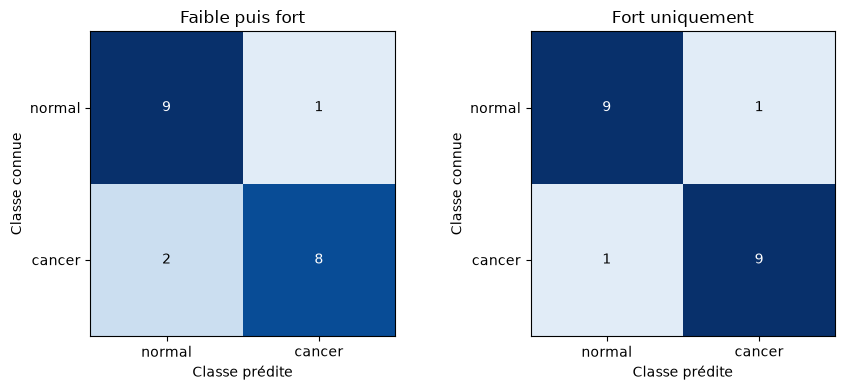

Écart de F1 cancer (semi-supervisé - supervisé) : -0.058
Sur ce test, le modèle supervisé obtient un F1 cancer supérieur.


In [44]:
comparaison_etape4 = pd.DataFrame(
    [mesures_semi, mesures_supervise],
    index=["Semi-supervisé : faible puis fort", "Supervisé : fort uniquement"],
).rename(columns={
    "F1": "F1 cancer",
    "Précision": "Précision cancer",
    "Rappel": "Rappel cancer",
    "F2": "F2 cancer",
})
display(comparaison_etape4.round(3))

matrices_etape4 = [confusion_semi, confusion_supervise]
titres_etape4 = ["Faible puis fort", "Fort uniquement"]
maximum_effectifs = max(matrice.max() for matrice in matrices_etape4)
figure, axes = plt.subplots(1, 2, figsize=(9, 4))

for axe, matrice, titre in zip(axes, matrices_etape4, titres_etape4):
    axe.imshow(matrice, cmap="Blues", vmin=0, vmax=maximum_effectifs)
    axe.set_xticks([0, 1], ["normal", "cancer"])
    axe.set_yticks([0, 1], ["normal", "cancer"])
    axe.set_xlabel("Classe prédite")
    axe.set_ylabel("Classe connue")
    axe.set_title(titre)

    for ligne in range(2):
        for colonne in range(2):
            couleur = "white" if matrice[ligne, colonne] > maximum_effectifs / 2 else "black"
            axe.text(
                colonne, ligne, str(matrice[ligne, colonne]),
                ha="center", va="center", color=couleur
            )

plt.tight_layout()
plt.show()

ecart_f1 = mesures_semi["F1"] - mesures_supervise["F1"]
print(f"Écart de F1 cancer (semi-supervisé - supervisé) : {ecart_f1:+.3f}")

if ecart_f1 > 0:
    print("Sur ce test, le modèle semi-supervisé obtient un F1 cancer supérieur.")
elif ecart_f1 < 0:
    print("Sur ce test, le modèle supervisé obtient un F1 cancer supérieur.")
else:
    print("Sur ce test, les deux modèles obtiennent le même F1 cancer.")


### Comparer le train et le test pour repérer un surapprentissage

Évaluer les deux CNN déjà entraînés sur les 63 images du train fort et les 20 images du test fort, avec les vrais labels normal/cancer. `evaluer_cnn` réalise les prédictions sans modifier les poids. Le chargeur d'évaluation réutilise les images du train fort, sans les mélanger.

Afficher les mêmes métriques sur les deux jeux, les écarts train moins test en points pour l'accuracy et le F2, puis un graphique du F2. Un score beaucoup plus élevé sur le train peut indiquer un surapprentissage. L'écart seul ne le prouve pas, surtout avec seulement 20 images de test. Cette comparaison sert au bilan final, pas au choix des hyperparamètres.

,Modèle,Jeu,Images,Accuracy,F1 cancer,Précision cancer,Rappel cancer,F2 cancer
0,Semi-supervisé,Train fort,63,0.968,0.969,0.969,0.969,0.969
1,Semi-supervisé,Test fort,20,0.850,0.842,0.889,0.800,0.816
2,Supervisé,Train fort,63,0.952,0.952,0.968,0.938,0.943
3,Supervisé,Test fort,20,0.900,0.900,0.900,0.900,0.900


Semi-supervisé : écart train - test = +11.8 points d'accuracy et +15.2 points de F2 cancer.
Supervisé : écart train - test = +5.2 points d'accuracy et +4.3 points de F2 cancer.


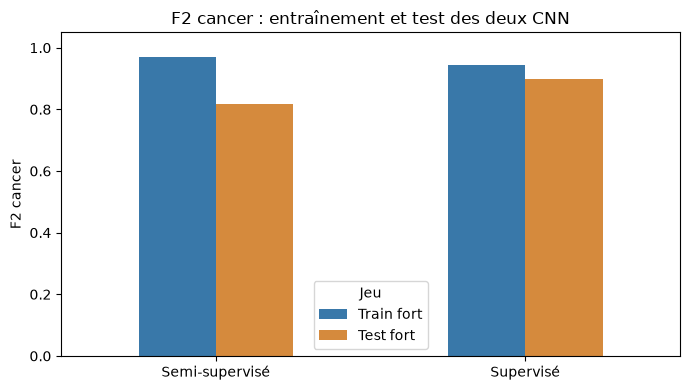

In [45]:

poids_semi_avant = {k:v.clone() for k,v in modele_semi.state_dict().items()}
poids_supervise_avant = {k:v.clone() for k,v in modele_supervise.state_dict().items()}
chargeur_train_evaluation = DataLoader(
    chargeur_fort.dataset,
    batch_size=taille_lot_etape4,
    shuffle=False,
    generator=torch.Generator().manual_seed(42),
)

resultats_train_test = []
for nom, cnn, mesures_test in [
    ("Semi-supervisé", modele_semi, mesures_semi),
    ("Supervisé", modele_supervise, mesures_supervise),
]:
    mesures_train, _ = evaluer_cnn(cnn, chargeur_train_evaluation)

    resultats_train_test.append({
        "Modèle": nom, "Jeu": "Train fort",
        "Images": len(chargeur_train_evaluation.dataset), **mesures_train,
    })
    resultats_train_test.append({
        "Modèle": nom, "Jeu": "Test fort",
        "Images": len(chargeur_test.dataset), **mesures_test,
    })

comparaison_train_test = pd.DataFrame(resultats_train_test)
display(comparaison_train_test.rename(columns={
    "F1": "F1 cancer", "Précision": "Précision cancer",
    "Rappel": "Rappel cancer", "F2": "F2 cancer",
}).round(3))

for nom in ["Semi-supervisé", "Supervisé"]:
    scores = comparaison_train_test.loc[
        comparaison_train_test["Modèle"] == nom
    ].set_index("Jeu")
    ecart_accuracy = 100 * (scores.loc["Train fort", "Accuracy"] - scores.loc["Test fort", "Accuracy"])
    ecart_f2 = 100 * (scores.loc["Train fort", "F2"] - scores.loc["Test fort", "F2"])
    print(f"{nom} : écart train - test = {ecart_accuracy:+.1f} points d'accuracy et {ecart_f2:+.1f} points de F2 cancer.")

scores_f2_train_test = comparaison_train_test.pivot(
    index="Modèle", columns="Jeu", values="F2"
).reindex(index=["Semi-supervisé", "Supervisé"], columns=["Train fort", "Test fort"])
axe = scores_f2_train_test.plot.bar(
    figsize=(7, 4), color=["#3978A9", "#D58A3D"], rot=0,
)
axe.set_title("F2 cancer : entraînement et test des deux CNN")
axe.set_xlabel("")
axe.set_ylabel("F2 cancer")
axe.set_ylim(0, 1.05)
axe.legend(title="Jeu")
plt.tight_layout()
plt.show()

In [46]:

assert all(torch.equal(v,modele_semi.state_dict()[k]) for k,v in poids_semi_avant.items())
assert all(torch.equal(v,modele_supervise.state_dict()[k]) for k,v in poids_supervise_avant.items())
assert len(chargeur_train_evaluation.dataset)==63
assert len(chargeur_test.dataset)==20
assert set(fortes_train.index).isdisjoint(fortes_test.index)
assert (comparaison_train_test.loc[comparaison_train_test.Jeu=="Test fort", "Accuracy"].to_numpy() == [mesures_semi["Accuracy"],mesures_supervise["Accuracy"]]).all()
Path(".build/brainscanai/overfit-check/results.json").write_text(comparaison_train_test.to_json(orient="records", force_ascii=False, indent=2),encoding="utf-8")
print("Check passed: unchanged model weights, separate train/test, consistent scores.")


Check passed: unchanged model weights, separate train/test, consistent scores.
